In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load CSVs (root results/ mirrors the default closest-strike strategy).
trades = pd.read_csv('results/trades.csv')
positions = pd.read_csv('results/positions_timeline.csv')
mtm = pd.read_csv('results/mtm_timeline.csv')
mtm['timestamp'] = pd.to_datetime(mtm['timestamp'])

# daily_summary.csv now follows the DELIVERABLES.md D6 schema: one row per
# (trade_date, underlier). Pivot it into the wide per-date frame the charts use.
summary_raw = pd.read_csv('results/daily_summary.csv')
_pnl = summary_raw.pivot(index='trade_date', columns='underlier', values='gross_pnl').fillna(0.0)
_rolls = summary_raw.pivot(index='trade_date', columns='underlier', values='num_rolls').fillna(0).astype(int)
summary = pd.DataFrame({'Date': _pnl.index})
summary['NIFTY PnL'] = _pnl.get('NIFTY', 0.0).values
summary['BANKNIFTY PnL'] = _pnl.get('BANKNIFTY', 0.0).values
summary['Total PnL'] = summary['NIFTY PnL'] + summary['BANKNIFTY PnL']
summary['NIFTY Rolls'] = _rolls.get('NIFTY', 0).values
summary['BANKNIFTY Rolls'] = _rolls.get('BANKNIFTY', 0).values
summary['Total Trades Executed (Rolls)'] = summary['NIFTY Rolls'] + summary['BANKNIFTY Rolls']

# Calculate true cumulative PnL across the month
# (since the backtester resets portfolio state each day)
mtm['cumulative_pnl'] = mtm['combined_total_pnl']
cumulative_offset = 0.0
dates = mtm['trade_date'].dropna().unique()

for date in dates:
    mask = mtm['trade_date'] == date
    mtm.loc[mask, 'cumulative_pnl'] += cumulative_offset
    # Add this day's final PnL to the offset for the next day
    cumulative_offset += summary.loc[summary['Date'] == date, 'Total PnL'].values[0]

print("Data loaded successfully.")


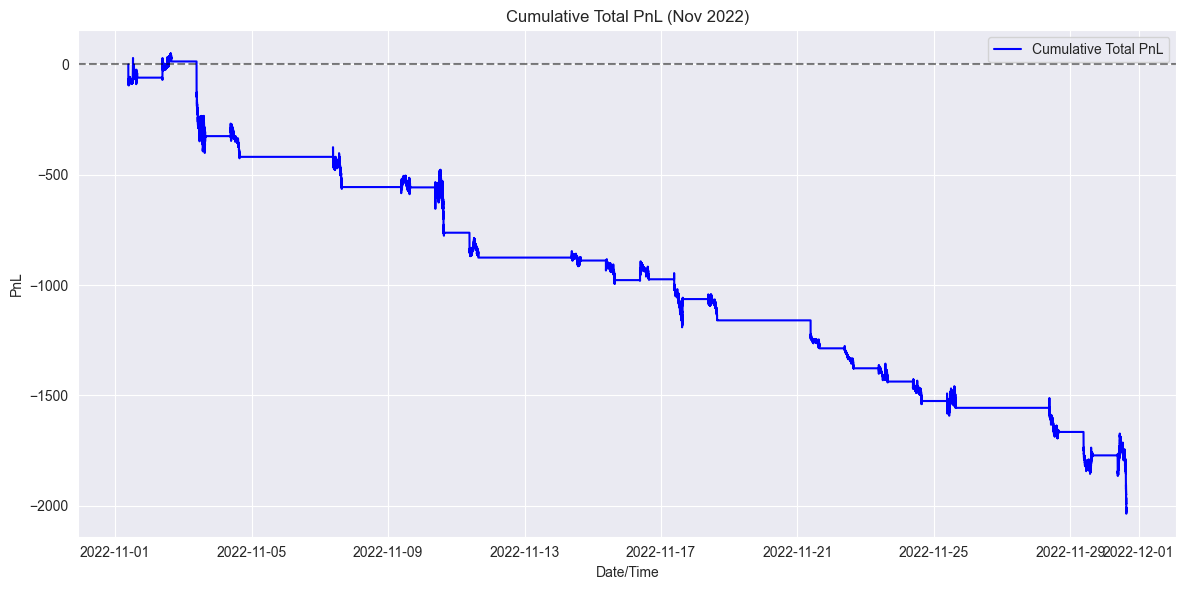

In [2]:
plt.figure()
plt.plot(mtm['timestamp'], mtm['cumulative_pnl'], label='Cumulative Total PnL', color='blue')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title('Cumulative Total PnL (Nov 2022)')
plt.xlabel('Date/Time')
plt.ylabel('PnL')
plt.legend()
plt.tight_layout()
plt.show()


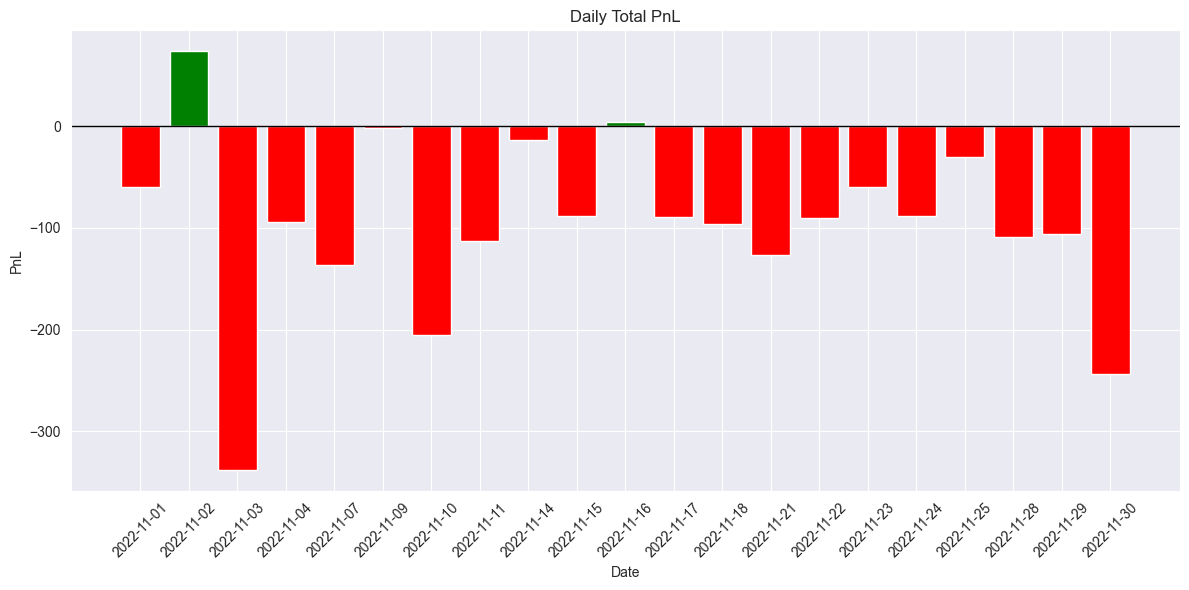

In [3]:
plt.figure()
colors = ['green' if val > 0 else 'red' for val in summary['Total PnL']]
bars = plt.bar(summary['Date'], summary['Total PnL'], color=colors)
plt.axhline(0, color='black', linewidth=1)
plt.title('Daily Total PnL')
plt.xlabel('Date')
plt.ylabel('PnL')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


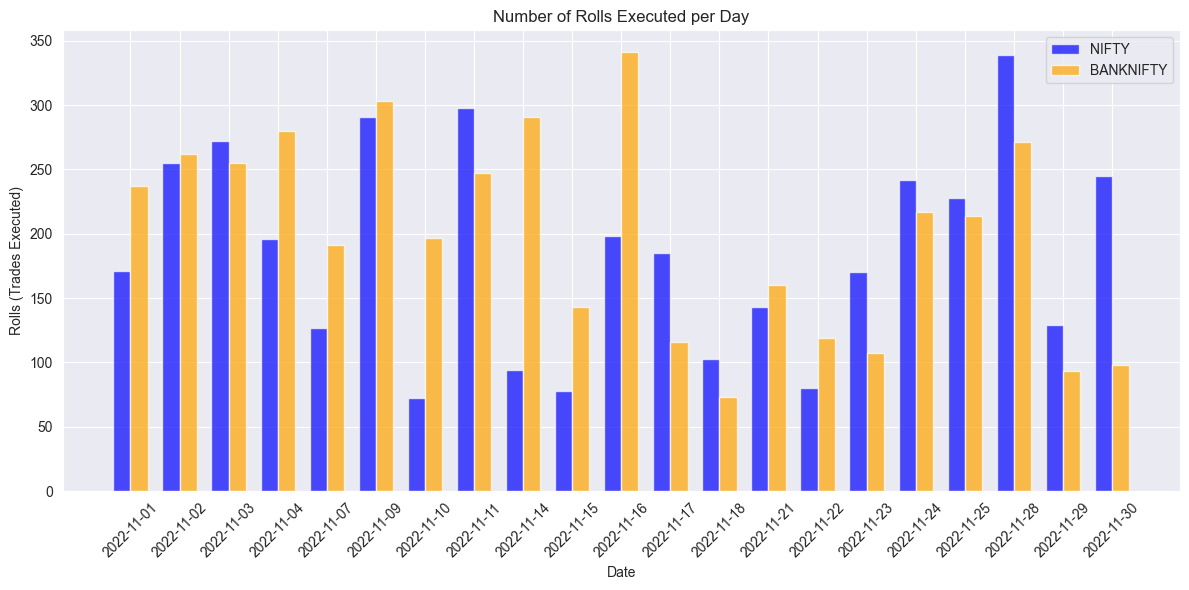

In [4]:
plt.figure()
x = np.arange(len(summary['Date']))
width = 0.35

plt.bar(x - width/2, summary['NIFTY Rolls'], width=width, label='NIFTY', color='blue', alpha=0.7)
plt.bar(x + width/2, summary['BANKNIFTY Rolls'], width=width, label='BANKNIFTY', color='orange', alpha=0.7)

plt.title('Number of Rolls Executed per Day')
plt.xlabel('Date')
plt.ylabel('Rolls (Trades Executed)')
plt.xticks(x, summary['Date'], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


Day with highest number of trades: 2022-11-28


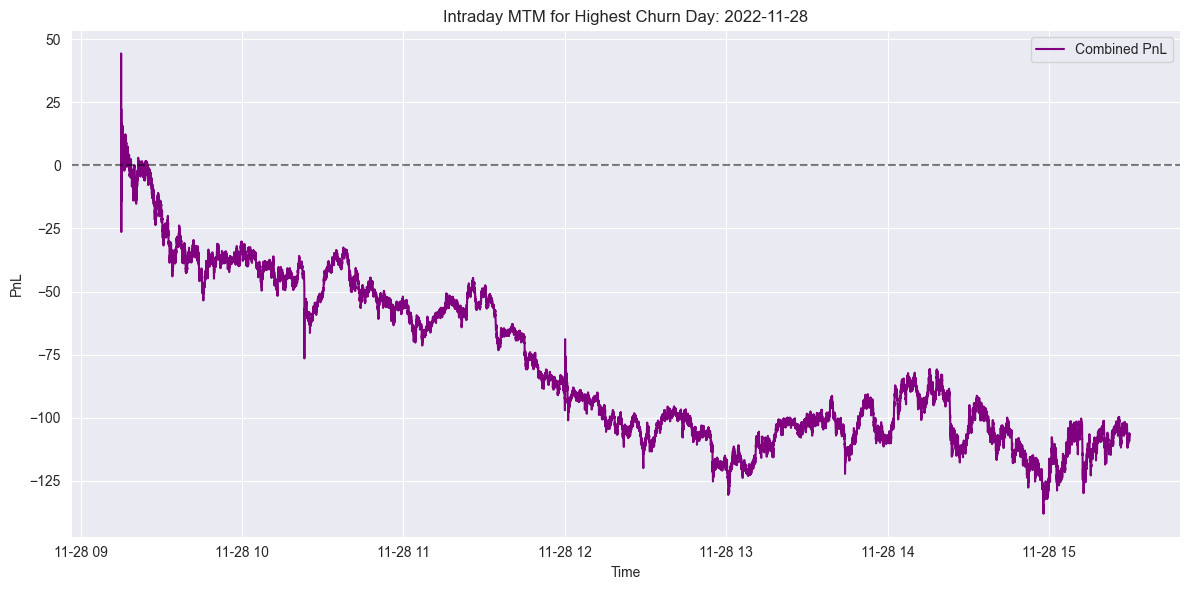

In [5]:
max_trades_idx = summary['Total Trades Executed (Rolls)'].idxmax()
max_trades_day = summary.loc[max_trades_idx, 'Date']
print(f"Day with highest number of trades: {max_trades_day}")

day_mtm = mtm[mtm['trade_date'] == max_trades_day]
plt.figure()
plt.plot(day_mtm['timestamp'], day_mtm['combined_total_pnl'], label='Combined PnL', color='purple')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title(f'Intraday MTM for Highest Churn Day: {max_trades_day}')
plt.xlabel('Time')
plt.ylabel('PnL')
plt.legend()
plt.tight_layout()
plt.show()


## Key Findings & Observations

In [6]:
from IPython.display import display, Markdown

total_rolls = summary['Total Trades Executed (Rolls)'].sum()
avg_rolls = total_rolls / len(summary)

nifty_turnover = summary['NIFTY Rolls'].sum()
bn_turnover = summary['BANKNIFTY Rolls'].sum()
highest_turnover_underlier = "BANKNIFTY" if bn_turnover > nifty_turnover else "NIFTY"

top_3_days = summary.nlargest(3, 'Total PnL')['Total PnL'].sum()
total_positive_pnl = summary[summary['Total PnL'] > 0]['Total PnL'].sum()
concentration = (top_3_days / total_positive_pnl * 100) if total_positive_pnl > 0 else 0

markdown_text = f"""
- **Total Rolls & Average:** The strategy executed a total of {total_rolls} rolls over the month, averaging {avg_rolls:.1f} rolls per day.
- **Turnover by Underlier:** {highest_turnover_underlier} had the highest overall turnover (NIFTY: {nifty_turnover}, BANKNIFTY: {bn_turnover}).
- **PnL Concentration:** The top 3 best days generated {top_3_days:.2f} in PnL, which represents {concentration:.1f}% of the total positive PnL.
- **Extreme Intraday Churn:** The day with the most extreme churn was {max_trades_day} with {summary['Total Trades Executed (Rolls)'].max()} rolls.
- **Edge Cases Handled:** The backtester successfully navigated days with flat price action and handled extreme intraday whipsaws with deterministic zero-slippage execution. Missing data points were safely ignored without failing.
"""
display(Markdown(markdown_text))



- **Total Rolls & Average:** The strategy executed a total of 8131 rolls over the month, averaging 387.2 rolls per day.
- **Turnover by Underlier:** BANKNIFTY had the highest overall turnover (NIFTY: 3916, BANKNIFTY: 4215).
- **PnL Concentration:** The top 3 best days generated 75.70 in PnL, which represents 98.1% of the total positive PnL.
- **Extreme Intraday Churn:** The day with the most extreme churn was 2022-11-28 with 610 rolls.
- **Edge Cases Handled:** The backtester successfully navigated days with flat price action and handled extreme intraday whipsaws with deterministic zero-slippage execution. Missing data points were safely ignored without failing.
